<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%9E%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%7C_%D0%94%D0%97_Ultra_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Домашнее задание Ultra Pro: обработка текстов с помощью нейросетей**

На этот раз задача усложняется: нужно распознать 20 русских писателей, а не 6, как раньше. Для этого потребуется более объёмная база данных для обучения. Ячейка для скачивания базы данных уже есть в ноутбуке с заданием.

**Задание состоит из нескольких этапов:**
1. Скачайте базу данных по предоставленной ссылке и подготовьте файлы базы для обработки.
2. Создайте обучающую и проверочную выборки, уделяя особое внимание балансировке базы: количество примеров каждого класса должно быть примерно одинаковым. Используйте цикл для разбивки данных. Проверочная выборка должна составлять 20% от общей выборки.
3. Подготовьте данные для обучения и обучите сеть. Добейтесь точности сети не менее 95% на проверочной выборке модели Bag of Words и 75–80% — для модели Embedding. Каждый пункт задания важен


## Загрузка данных

In [2]:
import gdown                                      # Подключим функцию gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip', None, quiet=True)      # Скачивание файла

'20writers.zip'

In [1]:
# Распаковка архива в папку writers
!unzip -qo 20writers.zip -d 20writers/

# Просмотр содержимого папки
!ls 20writers

Беляев.txt    Гончаров.txt     Каверин.txt    Лесков.txt     Толстой.txt
Булгаков.txt  Горький.txt      Катаев.txt     Носов.txt      Тургенев.txt
Васильев.txt  Грибоедов.txt    Куприн.txt     Пастернак.txt  Чехов.txt
Гоголь.txt    Достоевский.txt  Лермонтов.txt  Пушкин.txt     Шолохов.txt


In [2]:
# Работа с массивами данных
import numpy as np

# Работа с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Заполнение последовательностей до определенной длины
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Загрузка датасетов из облака google
import gdown

# Для работы с файлами в Colaboratory
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

In [3]:
# Настройка констант для загрузки данных
FILE_DIR  = '20writers'                     # Папка с текстовыми файлами

# Загрузка датасета. Добавляются имена классов и соответствующие тексты.
# Все тексты преобразуются в строку и объединяются для каждого класса и выборки
CLASS_LIST = []
texts_list = []

for file_name in os.listdir(FILE_DIR):
    class_name = file_name.replace('.txt', '')
    # Добавление нового класса, если его еще нет в списке
    if class_name not in CLASS_LIST:
        print(f'Добавление класса "{class_name}"')
        CLASS_LIST.append(class_name)
        # Инициализация соответствующих классу строк текста
        texts_list.append('')
    # Поиск индекса класса для добавления содержимого файла в выборку
    cls = CLASS_LIST.index(class_name)
    print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}"')
    with open(f'{FILE_DIR}/{file_name}', 'r') as f:
        # Загрузка содержимого файла в строку
        text = f.read()
    # Добавление текста к соответствующей выборке класса. Концы строк заменяются на пробел
    texts_list[cls] += ' ' + text.replace('\n', ' ')

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

Добавление класса "Достоевский"
Добавление файла "Достоевский.txt" в класс "Достоевский"
Добавление класса "Васильев"
Добавление файла "Васильев.txt" в класс "Васильев"
Добавление класса "Горький"
Добавление файла "Горький.txt" в класс "Горький"
Добавление класса "Тургенев"
Добавление файла "Тургенев.txt" в класс "Тургенев"
Добавление класса "Толстой"
Добавление файла "Толстой.txt" в класс "Толстой"
Добавление класса "Шолохов"
Добавление файла "Шолохов.txt" в класс "Шолохов"
Добавление класса "Лесков"
Добавление файла "Лесков.txt" в класс "Лесков"
Добавление класса "Пушкин"
Добавление файла "Пушкин.txt" в класс "Пушкин"
Добавление класса "Гоголь"
Добавление файла "Гоголь.txt" в класс "Гоголь"
Добавление класса "Беляев"
Добавление файла "Беляев.txt" в класс "Беляев"
Добавление класса "Носов"
Добавление файла "Носов.txt" в класс "Носов"
Добавление класса "Лермонтов"
Добавление файла "Лермонтов.txt" в класс "Лермонтов"
Добавление класса "Пастернак"
Добавление файла "Пастернак.txt" в класс

In [4]:
# Узнаем объём каждого текста в словах и символах
texts_len = [len(text) for text in texts_list]

# Устанавливаем "счётчик" номера текста
t_num = 0

# Выводим на экран  информационное сообщение
print(f'Размеры текстов по порядку (в токенах):')

# Циклом проводим итерацию по списку с объёмами текстов
for text_len in texts_len:

  # Запускаем "счётчик" номера текста
  t_num += 1

  # Выводим на экран сообщение о номере и объёме текста
  print(f'Текст №{t_num}: {text_len}')


Размеры текстов по порядку (в токенах):
Текст №1: 5178951
Текст №2: 2952793
Текст №3: 2523381
Текст №4: 1980207
Текст №5: 3357062
Текст №6: 3386269
Текст №7: 2152215
Текст №8: 3408340
Текст №9: 1965120
Текст №10: 2255255
Текст №11: 2399414
Текст №12: 1972542
Текст №13: 3089427
Текст №14: 1992831
Текст №15: 969110
Текст №16: 6611628
Текст №17: 3104713
Текст №18: 2328901
Текст №19: 2579247
Текст №20: 2001065


In [5]:
# Создаём список с вложенным циклом по длинам текстов, где i - 100% текста, i/5 - 20% текста
train_len_shares = [(i - round(i/5)) for i in texts_len]

# Устанавливаем "счётчик" номера текста
t_num = 0

# Циклом проводим итерацию по списку с объёмами текстов равными 80% от исходных
for train_len_share in train_len_shares:

  # Запускаем "счётчик" номера текста
  t_num += 1

  # Выводим на экран сообщение о номере и объёме текста в 80% от исходного
  print(f'Доля 80% от текста №{t_num}: {train_len_share} символов')

Доля 80% от текста №1: 4143161 символов
Доля 80% от текста №2: 2362234 символов
Доля 80% от текста №3: 2018705 символов
Доля 80% от текста №4: 1584166 символов
Доля 80% от текста №5: 2685650 символов
Доля 80% от текста №6: 2709015 символов
Доля 80% от текста №7: 1721772 символов
Доля 80% от текста №8: 2726672 символов
Доля 80% от текста №9: 1572096 символов
Доля 80% от текста №10: 1804204 символов
Доля 80% от текста №11: 1919531 символов
Доля 80% от текста №12: 1578034 символов
Доля 80% от текста №13: 2471542 символов
Доля 80% от текста №14: 1594265 символов
Доля 80% от текста №15: 775288 символов
Доля 80% от текста №16: 5289302 символов
Доля 80% от текста №17: 2483770 символов
Доля 80% от текста №18: 1863121 символов
Доля 80% от текста №19: 2063398 символов
Доля 80% от текста №20: 1600852 символов


In [6]:
text_train = []
text_test = []
for cls in range(len(CLASS_LIST)):
    text_train.append('')
    text_test.append('')
    text_train[cls] = texts_list[cls][:train_len_shares[cls]]
    text_test[cls] = texts_list[cls][train_len_shares[cls]:]
for i in range(CLASS_COUNT):
    print(CLASS_LIST[i], ':train:', text_train[i][:60])
    print(CLASS_LIST[i], ':test:', text_test[i][:60])

Достоевский :train:  ﻿СКАЗАНИЕ ОТЦА НАШЕГО АГАПИЯ,  ЗАЧЕМ ОСТАВЛЯЮТ СВОИ СЕМЬИ, 
Достоевский :test: помнили кстати, что по правилам на каждого арестанта из особ
Васильев :train:  ﻿А зори здесь тихие…1  В списках не значилсяЧасть первая1  
Васильев :test: одно объединённым русским силам: стремительная атака галичан
Горький :train:  ﻿МАКАР ЧУДРА* С моря дул влажный, холодный ветер, разнося п
Горький :test: епетно подхватила: Ви-ина душа-а не прима-ат… Мужик сладко у
Тургенев :train:  ﻿Дворянское гнездо Весенний, светлый день клонился к вечеру
Тургенев :test: вете лампадки бледное лицо отца и велел ему уйти; тот повино
Толстой :train:  ﻿ ГЛАВА I. ПОЕЗДКА НА ДОЛГИХ.  Снова поданы два экипажа к к
Толстой :test:  комнату. – Надо будет спросить у хозяина другую комнату, – 
Шолохов :train:  ﻿  Собрание сочинений в восьми томах  Том 1. Рассказы   I  
Шолохов :test: окопы как бы дымились, заштрихованные пылью. Теперь Григорий
Лесков :train:  ﻿ РАЗБОЙНИК Ехали мы к Макарью на ярмарку*. Тарантас б

In [13]:
VOCAB_SIZE = 20000                        # Объем словаря для токенизатора
WIN_SIZE   = 5000                         # Длина отрезка текста (окна) в словах
WIN_HOP    = 500                          # Шаг окна разбиения текста на векторы
tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ', oov_token='неизвестное_слово', char_level=False)

# Построение частотного словаря по обучающим текстам
tokenizer.fit_on_texts(text_train)
# Построение словаря в виде пар слово - индекс
items = list(tokenizer.word_index.items())
# Преобразование обучающих и проверочных текстов в последовательность индексов согласно частотному словарю
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)

In [14]:
# Функция разбиения последовательности на отрезки скользящим окном
# На входе - последовательность индексов, размер окна, шаг окна
def split_sequence(sequence, win_size, hop):
    # Последовательность разбивается на части до последнего полного окна
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]


# Функция формирования выборок из последовательностей индексов
# формирует выборку отрезков и соответствующих им меток классов в виде one hot encoding
def vectorize_sequence(seq_list, win_size, hop):
    # В списке последовательности следуют в порядке их классов
    # Всего последовательностей в списке ровно столько, сколько классов
    class_count = len(seq_list)

    # Списки для исходных векторов и категориальных меток класса
    x, y = [], []

    # Для каждого класса:
    for cls in range(class_count):
        # Разбиение последовательности класса cls на отрезки
        vectors = split_sequence(seq_list[cls], win_size, hop)
        # Добавление отрезков в выборку
        x += vectors
        # Для всех отрезков класса cls добавление меток класса в виде OHE
        y += [utils.to_categorical(cls, class_count)] * len(vectors)

    # Возврат результатов как numpy-массивов
    return np.array(x), np.array(y)

In [15]:
 # Формирование обучающей выборки
x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
# Формирование тестовой выборки
x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)

# Проверка формы сформированных данных
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

# Формирование выборок текстов в виде разреженных матриц (bag of words)
x_train_01 = tokenizer.sequences_to_matrix(x_train.tolist())
x_test_01 = tokenizer.sequences_to_matrix(x_test.tolist())
# Вывод формы обучающей выборки в виде разреженной матрицы Bag of Words
print(x_train_01.shape)
# Вывод фрагмента отрезка обучающего текста в виде Bag of Words
print(x_train_01[0][0:100])

(13666, 5000) (13666, 20)
(3292, 5000) (3292, 20)
(13666, 20000)
[0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1.
 1. 1. 1. 0.]


In [16]:

# Функция компиляции и обучения модели нейронной сети
def compile_train_model(model,
                        x_train,
                        y_train,
                        x_val,
                        y_val,
                        optimizer='adam',
                        epochs=50,
                        batch_size=128,
                        figsize=(20, 5)):

    # Компиляция модели
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Вывод сводки
    model.summary()

    # Обучение модели с заданными параметрами
    history = model.fit(x_train,
                        y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    # Вывод графиков точности и ошибки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


# Функция вывода результатов оценки модели на заданных данных
def eval_model(model, x, y_true,
               class_labels=[],
               cm_round=3,
               title='',
               figsize=(10, 10)):
    # Вычисление предсказания сети
    y_pred = model.predict(x)
    # Построение матрицы ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, cm_round)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Нейросеть {title}: матрица ошибок нормализованная', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Стирание ненужной цветовой шкалы
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси при необходимости
    plt.show()

    print('-'*100)
    print(f'Нейросеть: {title}')

    # Для каждого класса:
    for cls in range(len(class_labels)):
        # Определяется индекс класса с максимальным значением предсказания (уверенности)
        cls_pred = np.argmax(cm[cls])
        # Формируется сообщение о верности или неверности предсказания
        msg = 'ВЕРНО :-)' if cls_pred == cls else 'НЕВЕРНО :-('
        # Выводится текстовая информация о предсказанном классе и значении уверенности
        print('Класс: {:<20} {:3.0f}% сеть отнесла к классу {:<20} - {}'.format(class_labels[cls],
                                                                               100. * cm[cls, cls_pred],
                                                                               class_labels[cls_pred],
                                                                               msg))

    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))


# Совместная функция обучения и оценки модели нейронной сети
def compile_train_eval_model(model,
                             x_train,
                             y_train,
                             x_test,
                             y_test,
                             class_labels=CLASS_LIST,
                             title='',
                             optimizer='adam',
                             epochs=20,
                             batch_size=16,
                             graph_size=(20, 5),
                             cm_size=(10, 10)):

    # Компиляция и обучение модели на заданных параметрах
    # В качестве проверочных используются тестовые данные
    compile_train_model(model,
                        x_train, y_train,
                        x_test, y_test,
                        optimizer=optimizer,
                        epochs=epochs,
                        batch_size=batch_size,
                        figsize=graph_size)

    # Вывод результатов оценки работы модели на тестовых данных
    eval_model(model, x_test, y_test,
               class_labels=class_labels,
               title=title,
               figsize=cm_size)

In [17]:
# Создание последовательной модели нейросети
model_text_bow_softmax = Sequential()
# Первый полносвязный слой
model_text_bow_softmax.add(Dense(200, input_dim=VOCAB_SIZE, activation="relu"))
# Слой регуляризации Dropout
model_text_bow_softmax.add(Dropout(0.25))
model_text_bow_softmax.add(Dense(20, input_dim=VOCAB_SIZE, activation="relu"))
# Слой регуляризации Dropout
model_text_bow_softmax.add(Dropout(0.25))
# Слой пакетной нормализации
model_text_bow_softmax.add(BatchNormalization())
# Выходной полносвязный слой
model_text_bow_softmax.add(Dense(CLASS_COUNT, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 200)                 │       4,000,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 20)                  │           4,020 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 20)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 20)                  │              80 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 20)                  │             420 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,004,720 (15.28 MB)

 Trainable params: 4,004,680 (15.28 MB)

 Non-trainable params: 40 (160.00 B)

Epoch 1/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6667 - loss: 1.4061 - val_accuracy: 0.9578 - val_loss: 0.3346
Epoch 2/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9547 - loss: 0.2378 - val_accuracy: 0.9478 - val_loss: 0.2978
Epoch 3/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9630 - loss: 0.1624 - val_accuracy: 0.9560 - val_loss: 0.2279
Epoch 4/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9691 - loss: 0.1217 - val_accuracy: 0.9587 - val_loss: 0.1636
Epoch 5/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9665 - loss: 0.1102 - val_accuracy: 0.9602 - val_loss: 0.1716
Epoch 6/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9734 - loss: 0.0923 - val_accuracy: 0.9690 - val_loss: 0.1594
Epoch 7/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9745 - loss: 0.0831 - val_accuracy: 0.9502 - val_loss: 0.1890
Epoch 8/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9751 - loss: 0.0787 - val_accuracy: 0

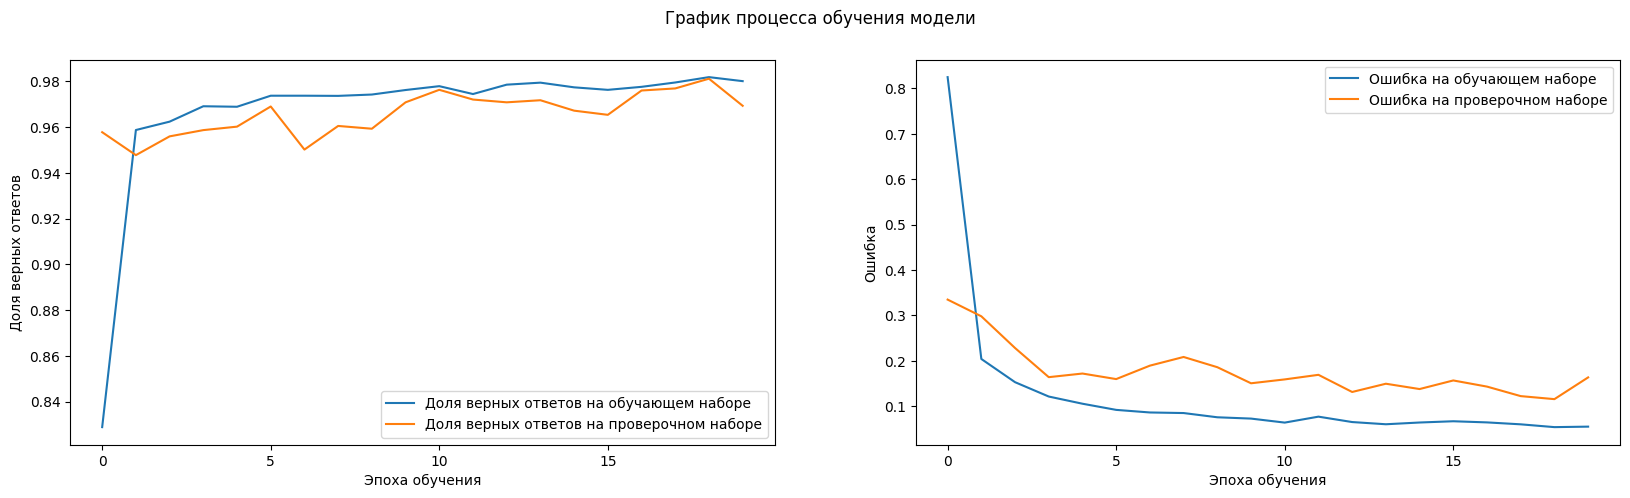

103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


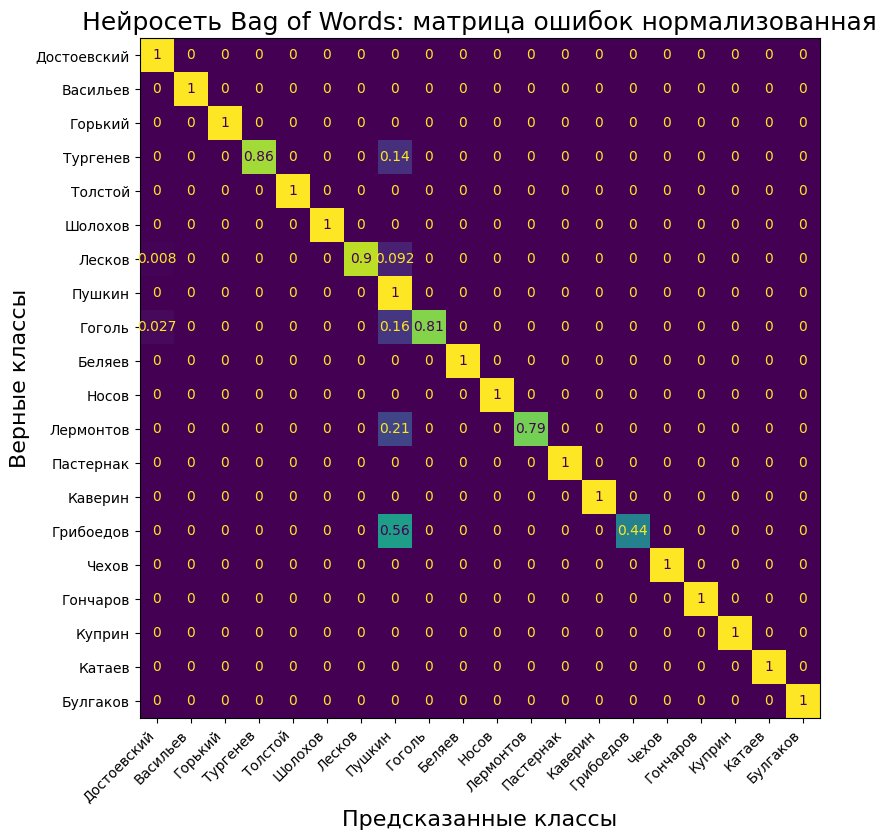

----------------------------------------------------------------------------------------------------
Нейросеть: Bag of Words
Класс: Достоевский          100% сеть отнесла к классу Достоевский          - ВЕРНО :-)
Класс: Васильев             100% сеть отнесла к классу Васильев             - ВЕРНО :-)
Класс: Горький              100% сеть отнесла к классу Горький              - ВЕРНО :-)
Класс: Тургенев              86% сеть отнесла к классу Тургенев             - ВЕРНО :-)
Класс: Толстой              100% сеть отнесла к классу Толстой              - ВЕРНО :-)
Класс: Шолохов              100% сеть отнесла к классу Шолохов              - ВЕРНО :-)
Класс: Лесков                90% сеть отнесла к классу Лесков               - ВЕРНО :-)
Класс: Пушкин               100% сеть отнесла к классу Пушкин               - ВЕРНО :-)
Класс: Гоголь                81% сеть отнесла к классу Гоголь               - ВЕРНО :-)
Класс: Беляев               100% сеть отнесла к классу Беляев               - ВЕРНО

In [18]:
compile_train_eval_model(model_text_bow_softmax,
                         x_train_01, y_train,
                         x_test_01, y_test,
                         class_labels=CLASS_LIST,
                         title='Bag of Words')